In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from functools import partial
import pickle
import scipy.stats as stats
from importlib import reload
import itertools
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from models.lead_lag_measure import get_lead_lag_matrix
from models.herm_matrix_algo import get_ordered_clustering
import real_data.utils
from real_data.utils import get_ordered_matrix, compute_jaccard, compute_flow_graph, plot_flow_heatmap, \
    plot_flow_network
import real_data.rolling_utils
from real_data.rolling_utils import get_rolling_lead_lag_matrix, get_cluster_rolling_metric, get_flow_graph_rolling
import scipy.stats as stats
from real_data.utils import winsorize_stock, standardize_returns

In [2]:
import importlib
import real_data.utils as thf
importlib.reload(thf)

<module 'real_data.utils' from '/Users/zheguan/DDA/Signature/Bit/newrepo/Bit_regime_match/strategy_performance/real_data/utils.py'>

In [3]:
# Read the CSV file
df1 = pd.read_csv('../data/daily_price.csv')

data = df1.set_index('ticker')

data

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
ticker,,,,,,,,,,,,,,,,,,,,,
1/1/2021,0.04210,0.008912,0.019052,1.3587,728.91,2.6378,NaN,0.36169,0.012224,4.0817,...,0.13561,NaN,0.23746,0.02685,5.861,90.711,0.005680,14.461,0.036973,2.268
1/2/2021,0.04095,0.008557,0.019993,1.4124,774.56,2.6321,NaN,0.32751,0.011317,3.6083,...,0.13156,NaN,0.22064,0.02721,5.420,85.768,0.010526,14.426,0.038107,2.249
1/3/2021,0.04129,0.008610,0.026226,1.4707,978.28,2.7985,NaN,0.29857,0.009871,4.4294,...,0.13500,NaN,0.22540,0.02949,5.829,93.778,0.009821,16.024,0.040928,2.466
1/4/2021,0.04135,0.008397,0.024598,1.3868,1041.43,2.8191,NaN,0.30888,0.010121,4.3500,...,0.14105,NaN,0.23565,0.03095,6.044,114.271,0.009761,16.372,0.040432,2.515
1/5/2021,0.04394,0.008499,0.027964,1.4953,1099.56,2.8862,NaN,0.33823,0.010981,4.5700,...,0.14654,NaN,0.22573,0.02852,6.196,119.689,0.009970,16.868,0.041700,2.612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6/26/2024,0.09229,0.030890,0.025950,5.1770,3371.44,0.5750,0.2740,0.21870,0.001415,23.0400,...,0.19980,2.151,0.46980,0.12268,6.791,94.460,0.122760,11.340,0.334000,2.566
6/27/2024,0.09734,0.031490,0.026690,5.2230,3450.44,0.5894,0.2786,0.21780,0.001451,23.2400,...,0.19620,2.182,0.47530,0.12201,6.965,93.460,0.127110,11.620,0.340700,2.607
6/28/2024,0.09674,0.030630,0.026650,4.9620,3380.15,0.5875,0.2672,0.20730,0.001418,23.0700,...,0.19100,2.134,0.47160,0.12321,6.729,93.640,0.123060,11.400,0.336100,2.571


In [4]:
# row t: gives the log return going from the close at day t - 1 to close at day t
daily_ret = np.log(data).ffill().diff().shift(-1).fillna(0)
daily_ret = daily_ret[:-1]
close_price = data.shift(-1).fillna(0)
close_price = close_price[:-1]
daily_ret = np.log(data).ffill().diff().fillna(0)
daily_ret = daily_ret[1:]
close_price = data[1:]

In [5]:
# Apply the function to each column (stock)
daily_ret = daily_ret.apply(winsorize_stock, lower_percentile=0.025, upper_percentile=0.975)

In [6]:
daily_ret.describe()

,ROSE,ANKR,VET,NEAR,ETH,EOS,BAKE,GRT,REEF,INJ,...,ENJ,CAKE,XRP,TRX,ATOM,AAVE,DOGE,NEO,SAND,QTUM
count,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,...,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000
mean,0.000810,0.000477,0.000485,0.000868,0.001444,-0.001100,-0.002834,-0.000654,-0.001050,0.001740,...,0.000110,-0.001629,-0.000389,0.001082,0.000364,0.000227,0.001180,-0.000099,0.000385,0.000026
std,0.057853,0.051228,0.049198,0.059338,0.036760,0.044803,0.055807,0.056779,0.053173,0.061438,...,0.054552,0.043477,0.039897,0.033567,0.051310,0.051551,0.052678,0.046783,0.056759,0.049709
min,-0.126276,-0.115381,-0.112083,-0.132678,-0.087733,-0.118940,-0.143364,-0.128403,-0.124426,-0.135480,...,-0.122273,-0.112093,-0.098959,-0.093753,-0.113157,-0.118320,-0.110154,-0.111055,-0.134184,-0.115339
25%,-0.032884,-0.029607,-0.027533,-0.032568,-0.017723,-0.023444,-0.031005,-0.034420,-0.030304,-0.034315,...,-0.031973,-0.022240,-0.020526,-0.013947,-0.028267,-0.029532,-0.027122,-0.026015,-0.030927,-0.026266
50%,-0.000098,0.001587,0.000652,-0.000798,0.000927,0.000000,0.000000,-0.001516,0.000000,-0.000835,...,0.001472,0.000000,0.000060,0.002333,0.000371,0.000020,-0.000645,0.002216,-0.000272,0.002242
75%,0.031302,0.027897,0.027477,0.033793,0.021865,0.023824,0.028573,0.030803,0.027496,0.034874,...,0.029604,0.020097,0.020227,0.015931,0.027073,0.028842,0.021321,0.027133,0.029209,0.026291
max,0.150636,0.125301,0.125841,0.144168,0.087468,0.105065,0.126132,0.140632,0.126721,0.154830,...,0.138115,0.106142,0.102540,0.094108,0.131534,0.122575,0.171577,0.105118,0.151228,0.129443


In [7]:
daily_ret = standardize_returns(daily_ret)

In [8]:
target_dir = "/Users/zheguan/DDA/Signature/Bit/newrepo/Bit_regime_match/strategy_performance/"
os.chdir(target_dir)

In [9]:
daily_ret.to_csv('/Users/zheguan/DDA/Signature/Bit/newrepo/Bit_regime_match/strategy_performance/data/binance_real_data/daily_returns.csv')
daily_ret.to_pickle('/Users/zheguan/DDA/Signature/Bit/newrepo/Bit_regime_match/strategy_performance/data/binance_real_data/daily_returns.pkl')

In [10]:
daily_ret = daily_ret.rename_axis("date")

In [11]:
log_ret_type = '' # '_residuals'
correlation_method = 'mutual_information'
method = 'signature'

lead_lag_matrix = pd.read_pickle('/Users/zheguan/DDA/Signature/Bit/test/mlj-lead-lag/code/strategy_performance/data/binance_pickled_data/lead_lag_matrix' + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')

In [ ]:
#generate lead-lag matrices

log_ret_type = ''  # _residuals
lookback = 30 # 1 month lookback period
update_freq = 1 # (1, 7, 14, 30)
correlation_method = 'pearson'  # ''
method = 'ccf_at_max_lag'

daily_ret.index = pd.to_datetime(daily_ret.index)

lead_lag_matrix_rolling = get_rolling_lead_lag_matrix(daily_ret, lookback=lookback,
                                                      update_freq=update_freq,
                                                      method=method, max_lag=7, correlation_method=correlation_method)
lead_lag_matrix_rolling.to_pickle('./data/binance_pickled_data/lead_lag_matrix_rolling' + '_lookback_' + str(lookback) +
                                  '_update_freq_' + str(update_freq) + log_ret_type + '_' + correlation_method + '_' + method + '.pkl')


In [12]:
#read stored matrices

lookback = 30
update_freq = 1
log_ret_type = ''
correlation_method = 'pearson'

base_path = './data/binance_pickled_data/lead_lag_matrix_rolling'
path_ccf = f'{base_path}_lookback_{lookback}_update_freq_{update_freq}{log_ret_type}_{correlation_method}_ccf_at_max_lag.pkl'
path_sig = f'{base_path}_lookback_{lookback}_update_freq_{update_freq}{log_ret_type}_pearson_signature.pkl'
path_dis = f'{base_path}_lookback_{lookback}_update_freq_{update_freq}{log_ret_type}_distance_ccf_at_max_lag.pkl'

lead_lag_ccf = pd.read_pickle(path_ccf)
lead_lag_sig = pd.read_pickle(path_sig)
lead_lag_dis = pd.read_pickle(path_dis)
lead_lag_ccf = lead_lag_ccf[lead_lag_ccf.index >= '2021-05-01']
lead_lag_sig = lead_lag_sig[lead_lag_sig.index >= '2021-05-01']
lead_lag_dis = lead_lag_dis[lead_lag_dis.index >= '2021-05-01']



In [13]:
#quick check
date_to_view = '2024-06-25'

daily_matrix = lead_lag_ccf.loc[date_to_view]

print(daily_matrix) 

          ROSE      ANKR       VET      NEAR       ETH       EOS      BAKE  \
ROSE  0.000000 -0.054290 -0.260282  0.000285  0.023042 -0.053994  0.156886   
ANKR  0.054290  0.000000 -0.148771 -0.126522 -0.119186  0.058079  0.025637   
VET   0.260282  0.148771  0.000000  0.098896  0.031097  0.258783  0.113566   
NEAR -0.000285  0.126522 -0.098896  0.000000  0.116063  0.158084  0.108522   
ETH  -0.023042  0.119186 -0.031097 -0.116063  0.000000  0.191760  0.000178   
...        ...       ...       ...       ...       ...       ...       ...   
AAVE  0.202107  0.045371 -0.043291 -0.037836 -0.031532  0.109408  0.033463   
DOGE  0.147241  0.094485 -0.128596  0.058384 -0.056049  0.080733 -0.096268   
NEO   0.076974  0.096558 -0.139586 -0.070407 -0.065658  0.158077  0.066211   
SAND  0.086102  0.119950 -0.153922 -0.009651 -0.045429  0.100855  0.127179   
QTUM  0.144461  0.148410 -0.119842  0.098469 -0.029609  0.185698  0.188413   

           GRT      REEF       INJ  ...       ENJ      CAKE    

In [14]:
prices = data

In [74]:
import numpy as np
import pandas as pd

def backtest_btc_regime_sign_overlay(
    prices: pd.DataFrame,
    lead_lag_matrix_rolling: pd.DataFrame,
    dir_signal: pd.Series,                  # 0/1/2 (bear/neutral/bull)
    *,
    btc_col: str = "BTC",
    orientation: str = "row",               # "row": M.loc[BTC]; "col": M[BTC]
    quantile: float = 0.2,
    min_names: int = 3,
    use_log_returns: bool = True,

    apply_to_leaders: bool = True,
    preserve_baseline_hedge: bool = False,
    abs_rel_quantile: float | None = 0.5,

    # ⇩ New: neutral handling mode
    neutral_mode: str = "baseline",         # "baseline" | "gating" | "scale"
    neutral_scale: float = 0.5,             # Effective only when neutral_mode="scale"
) -> pd.Series:
    px = prices.copy()
    px.index = pd.to_datetime(px.index).tz_localize(None).sort_values()
    rets = (np.log(px).diff() if use_log_returns else px.pct_change()).dropna(how="all")
    rets.index = pd.to_datetime(rets.index).tz_localize(None)
    r_idx = rets.index
    if btc_col not in rets.columns:
        raise KeyError(f"{btc_col} not found in prices columns")

    def next_trading_day(d):
        # First trading day strictly after timestamp d
        i = r_idx.searchsorted(pd.Timestamp(d), side="right")
        return None if i >= len(r_idx) else r_idx[i]

    L = lead_lag_matrix_rolling.copy()
    L.index = pd.to_datetime(L.index).tz_localize(None)
    L = L.sort_index()
    L = L[~L.index.duplicated(keep="last")]

    ds = pd.Series(dir_signal).copy()
    ds.index = pd.to_datetime(ds.index).tz_localize(None).normalize()
    ds = ds.sort_index()
    ds = ds[~ds.index.duplicated(keep="last")]

    out, dates = [], []

    for d in L.index:
        # Regime label as of day d (carry-forward)
        z = ds.asof(pd.Timestamp(d)) if len(ds) else pd.NA
        if pd.isna(z): 
            continue
        z = int(z)

        next_day = next_trading_day(d)
        if next_day is None:
            continue
        r_next = rets.loc[next_day]

        M = L.loc[d]
        if isinstance(M, pd.DataFrame):
            if M.isnull().all().all(): 
                continue
            # Aggregate scores across columns (e.g., average)
            s_scores = M.mean(axis=1).astype(float)
        else:
            # If not a square matrix/DataFrame, cannot run baseline/sign split
            continue

        # Select leaders/followers by quantiles (consistent with the baseline overlay)
        pos_scores = s_scores[s_scores > 0]
        neg_scores = s_scores[s_scores < 0]
        if len(pos_scores) == 0 or len(neg_scores) == 0:
            continue
        hi = pos_scores.quantile(1 - quantile)
        lo = neg_scores.quantile(quantile)
        leaders   = s_scores[s_scores >= hi].index
        followers = s_scores[s_scores <= lo].index

        if z == 1 and neutral_mode == "baseline":
            # Neutral regime: trade the baseline overlay directly
            if len(leaders) < min_names or len(followers) < min_names:
                continue
            long_set  = set(followers)
            short_set = set(leaders)

            long_ret  = r_next[list(long_set)].dropna().mean()
            short_ret = r_next[list(short_set)].dropna().mean()
            out.append(long_ret - short_ret)
            dates.append(next_day)
            continue

        if z == 1 and neutral_mode == "gating":
            # Neutral regime: no trades
            continue

        # Otherwise (bull/bear; or neutral with scaling): trade by BTC–asset sign relationships
        # Take the signed relationship BTC → asset
        rel = (M.loc[btc_col] if orientation == "row" else M[btc_col]).astype(float, errors="ignore")
        # Exclude BTC itself from the tradable universe
        universe = list((set(r_next.index) & set(rel.index)) - {btc_col})
        if not universe:
            continue
        rel = rel.loc[universe]

        # Strength filter: keep only large |rel|
        if abs_rel_quantile is not None:
            thr = rel.abs().quantile(abs_rel_quantile)
            rel = rel[rel.abs() >= thr]
            if rel.empty:
                continue

        def split_by_sign(names, flip: bool):
            """Split provided names into long/short buckets by sign of rel; flip for bear regime."""
            names = [n for n in names if n in rel.index]
            if not names:
                return [], []
            if not flip:
                long_names  = [n for n in names if rel[n] > 0]
                short_names = [n for n in names if rel[n] < 0]
            else:
                long_names  = [n for n in names if rel[n] < 0]
                short_names = [n for n in names if rel[n] > 0]
            return long_names, short_names

        flip = (z == 0)  # Flip long/short in bear regime
        long_set, short_set = set(), set()

        # Followers: split into long/short by sign
        Lf, Sf = split_by_sign(followers, flip=flip)
        long_set.update(Lf); short_set.update(Sf)

        # Leaders: optionally also split into long/short by sign
        if apply_to_leaders:
            Ll, Sl = split_by_sign(leaders, flip=flip)
            long_set.update(Ll); short_set.update(Sl)

        # Preserve the baseline hedge: always short leaders as a hedge
        if preserve_baseline_hedge:
            short_set.update([n for n in leaders if n in r_next.index])

        # Skip if there are not enough names on either side
        if len(long_set) < min_names or len(short_set) < min_names:
            continue

        long_ret  = r_next[list(long_set)].dropna().mean()
        short_ret = r_next[list(short_set)].dropna().mean()
        pnl = long_ret - short_ret

        # Neutral with scaling: downscale exposure/returns
        if z == 1 and neutral_mode == "scale":
            pnl *= float(neutral_scale)

        out.append(pnl)
        dates.append(next_day)

    return pd.Series(out, index=dates, name="btc_regime_sign")


In [75]:
import pandas as pd
from pathlib import Path

def batch_eval_btc_regime_sign(
    signal_dir,
    *,
    prices,
    lead_lag_matrix_rolling,
    file_glob="daily_dir_*_k5.csv",
    # Flip criterion
    criterion="sharpe",                 # "sharpe" or "annret"
    train_end=None,                     # e.g., "2023-12-31"; None = decide flip on full sample
    # Unified calendar for evaluation
    calendar_index=None,                # Recommend passing the price calendar: np.log(prices).diff().dropna().index
    ann_factor=365,                     # Crypto: 365; Equities: 252
    min_active_days=60,                 # Filter out results with too few active trading days
    # Backtest params (keep consistent with your overlay backtest)
    btc_col="BTC",
    orientation="row",
    quantile=0.2,
    min_names=3,
    use_log_returns=True,
    apply_to_leaders=False,
    preserve_baseline_hedge=True,
    abs_rel_quantile=0.8,
    neutral_mode="baseline",            # Key: treat neutral periods as baseline
    neutral_scale=0.5,                  # Only effective when neutral_mode="scale"
    save_csv=None
):
    signal_dir = Path(signal_dir)
    rows, rets_dict = [], {}

    files = sorted(signal_dir.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"未在 {signal_dir} 找到 {file_glob}")

    for fp in files:
        try:
            ds = read_daily_dir_signal_csv(fp)

            # — Backtest: overlay (neutral = baseline) —
            ret = backtest_btc_regime_sign_overlay(
                prices=prices,
                lead_lag_matrix_rolling=lead_lag_matrix_rolling,
                dir_signal=ds,
                btc_col=btc_col,
                orientation=orientation,
                quantile=quantile,
                min_names=min_names,
                use_log_returns=use_log_returns,
                apply_to_leaders=apply_to_leaders,
                preserve_baseline_hedge=preserve_baseline_hedge,
                abs_rel_quantile=abs_rel_quantile,
                neutral_mode=neutral_mode,
                neutral_scale=neutral_scale
            )
            if ret.empty or len(ret) < min_active_days:
                continue

            # — Decide whether to flip on the training segment —
            if train_end is not None:
                ret_train = ret.loc[:pd.to_datetime(train_end)]
                if ret_train.empty:  # If no trades in training segment, fall back to full sample
                    ret_train = ret
            else:
                ret_train = ret

            st_norm = evaluate_strategy_calendar(ret_train, calendar_index, ann_factor=ann_factor)
            st_flip = evaluate_strategy_calendar(-ret_train, calendar_index, ann_factor=ann_factor)

            if criterion.lower().startswith("ann"):
                score_norm = st_norm.get("Annual Return (%)", float("-inf"))
                score_flip = st_flip.get("Annual Return (%)", float("-inf"))
            else:
                score_norm = st_norm.get("Sharpe Ratio", float("-inf"))
                score_flip = st_flip.get("Sharpe Ratio", float("-inf"))

            flipped = bool(score_flip > score_norm)
            ret_final = (-ret if flipped else ret)
            stats_final = evaluate_strategy_calendar(ret_final, calendar_index, ann_factor=ann_factor)

            rows.append({
                "signal_file": fp.name,
                "flipped": flipped,
                "criterion": criterion,
                **stats_final
            })
            rets_dict[fp.name] = ret_final.rename(fp.name)

        except Exception as e:
            rows.append({
                "signal_file": fp.name,
                "flipped": None,
                "criterion": criterion,
                "error": str(e)
            })

    results = pd.DataFrame(rows).sort_values("Sharpe Ratio", ascending=False, na_position="last")
    if save_csv:
        results.to_csv(save_csv, index=False)
    return results, rets_dict


def evaluate_strategy_calendar(
    returns: pd.Series,
    calendar_index: pd.DatetimeIndex | None = None,
    risk_free_rate: float = 0.0,
    ann_factor: int | None = None,
):
    """
    Evaluate a strategy on a fixed calendar: missing days get 0 return; annualization uses the calendar frequency.
    - calendar_index: recommend using the price or baseline date index; if None, use a daily 'D' calendar covering [min, max].
    - ann_factor: explicitly specify (e.g., 365/252); if not provided, it will be inferred.
    """
    r = pd.Series(returns).dropna().sort_index()

    if calendar_index is None:
        start, end = pd.to_datetime(r.index.min()), pd.to_datetime(r.index.max())
        calendar_index = pd.date_range(start, end, freq="D")

    # Force to DatetimeIndex to avoid missing attributes on a plain Index
    calendar_index = pd.DatetimeIndex(calendar_index)

    r_full = r.reindex(calendar_index).fillna(0.0)

    if ann_factor is None:
        ann_factor = _guess_ann_factor(r_full.index)

    # Excess returns
    excess = r_full - risk_free_rate / ann_factor
    mu = excess.mean()
    sigma = excess.std(ddof=0)
    sharpe = np.nan if sigma == 0 else mu / sigma * np.sqrt(ann_factor)

    vol = r_full.std(ddof=0) * np.sqrt(ann_factor)
    nav = (1 + r_full).cumprod()

    T_years = len(r_full) / ann_factor
    ann_ret = (nav.iloc[-1]) ** (1 / max(T_years, 1e-9)) - 1
    mdd = (nav / nav.cummax() - 1).min()

    return {
        "Annual Return (%)": ann_ret * 100,
        "Sharpe Ratio": sharpe,
        "Volatility (%)": vol * 100,
        "Max Drawdown (%)": mdd * 100,
        "Calendar Days": int(len(r_full)),
        "Active Days": int(len(r)),
        "Active Ratio (%)": float(len(r) / len(r_full) * 100),
        "Final NAV": float(nav.iloc[-1]),
    }

from pathlib import Path
import numpy as np
import pandas as pd

signal_dir = "../notebooks/dataall/wf_outputs/signals"

# Unified calendar: use the price trading days (crypto is essentially daily)
price_calendar = pd.to_datetime(np.log(prices).diff().dropna().index)

results, rets_map = batch_eval_btc_regime_sign(
    signal_dir=signal_dir,
    prices=prices,
    lead_lag_matrix_rolling=lead_lag_sig,
    file_glob = "wf_current_only_s*H30*_wfstrict_rolling.csv",
    # file_glob="daily_dir_*_k5.csv",
    criterion="sharpe",
    train_end="2023-12-31",
    calendar_index=price_calendar,   
    ann_factor=365,                  
    min_active_days=120,             
    btc_col="BTC",
    orientation="row",
    quantile=0.1,                    
    min_names=2, use_log_returns=True,
    apply_to_leaders=True,
    preserve_baseline_hedge=True,
    abs_rel_quantile=None,
    neutral_mode="scale",           
    neutral_scale=0.5,               
    save_csv=str(Path(signal_dir)/"batch_eval_btc_sign_baselineNeutral.csv")
)

print(results.head(10))


                                          signal_file  flipped criterion  \
10  wf_current_only_s5_p20_o0_H30_wfstrict_rolling...    False    sharpe   
9   wf_current_only_s5_p16_o0_H30_wfstrict_rolling...    False    sharpe   
4   wf_current_only_s15_p12_o0_H30_wfstrict_rollin...    False    sharpe   
5   wf_current_only_s15_p16_o0_H30_wfstrict_rollin...    False    sharpe   
11  wf_current_only_s5_p8_o0_H30_wfstrict_rolling.csv    False    sharpe   
14  wf_current_only_s8_p20_o0_H30_wfstrict_rolling...    False    sharpe   
2   wf_current_only_s10_p20_o0_H30_wfstrict_rollin...    False    sharpe   
8   wf_current_only_s5_p12_o0_H30_wfstrict_rolling...    False    sharpe   
15  wf_current_only_s8_p8_o0_H30_wfstrict_rolling.csv    False    sharpe   
0   wf_current_only_s10_p12_o0_H30_wfstrict_rollin...     True    sharpe   

    Annual Return (%)  Sharpe Ratio  Volatility (%)  Max Drawdown (%)  \
10          30.098468      1.424426       19.850756        -14.148818   
9           21.14

In [53]:
def backtest_lead_lag_hedge(
    prices: pd.DataFrame,
    lead_lag_matrix_rolling: pd.DataFrame,
    quantile: float = 0.1,
    invert: bool = False,          # If True, swap the long/short legs
    min_names: int = 1,            # Minimum number of names per leg; skip the day if not met
    use_log_returns: bool = True,  # True: log returns; False: simple returns
) -> pd.Series:
    """
    Lead–Lag hedge: by default go long followers and short leaders; if `invert=True`, do the opposite.

    Parameters
    ----------
    prices : DataFrame
        Price table with trading dates as the index and assets as columns.
    lead_lag_matrix_rolling : DataFrame
        Time series (indexed by date) of rolling lead–lag matrices.
    quantile : float
        Tail quantile used to select leaders/followers (take one tail on the positive side
        for leaders and one tail on the negative side for followers).
    invert : bool
        If True, swap leaders and followers (i.e., reverse the direction).
    min_names : int
        Minimum number of assets required on each leg (long and short). If not satisfied, skip the day.
    use_log_returns : bool
        Whether to use log returns (True) or simple returns (False).

    Returns
    -------
    pd.Series
        Daily strategy returns aligned to the *next trading day*.
    """
    # --- Preprocess prices & returns ---
    px = prices.copy()
    px.index = pd.to_datetime(px.index)
    px = px.sort_index()
    if use_log_returns:
        rets = np.log(px).diff()
    else:
        rets = px.pct_change()
    rets = rets.dropna(how="all")

    # --- Helper: strictly find the next trading day > d ---
    r_index = rets.index
    def _next_trading_day(d: pd.Timestamp):
        pos = r_index.searchsorted(pd.Timestamp(d), side="right")
        if pos >= len(r_index):
            return None
        return r_index[pos]

    # --- Main loop ---
    daily_returns, backtest_dates = [], []
    L = lead_lag_matrix_rolling.copy()
    L.index = pd.to_datetime(L.index)
    L = L.sort_index()
    # Optional: drop duplicated timestamps, keep the last one
    L = L[~L.index.duplicated(keep="last")]

    for d in L.index:
        M = L.loc[d]
        # Skip if the matrix/series is all NaN
        if isinstance(M, pd.Series):
            all_nan = M.isna().all()
        else:
            all_nan = M.isnull().all().all()
        if all_nan:
            continue

        # Score per asset = row mean (if matrix), otherwise use the series directly
        lead_scores = M.mean(axis=1) if isinstance(M, pd.DataFrame) else M

        # Split into positive and negative sides; take tails by quantile
        pos_scores = lead_scores[lead_scores > 0]
        neg_scores = lead_scores[lead_scores < 0]

        if len(pos_scores) == 0 or len(neg_scores) == 0:
            # If either side is missing, leaders/followers cannot be defined under this convention
            continue

        top_thresh = pos_scores.quantile(1 - quantile)   # Positive tail → leaders
        bottom_thresh = neg_scores.quantile(quantile)     # Negative tail → followers

        leaders = lead_scores[lead_scores >= top_thresh].index
        followers = lead_scores[lead_scores <= bottom_thresh].index

        # Enforce minimum count on both legs
        if len(leaders) < min_names or len(followers) < min_names:
            continue

        # Optional direction flip
        if invert:
            leaders, followers = followers, leaders

        # Trade on the next trading day
        next_day = _next_trading_day(d)
        if next_day is None:
            continue

        r_next = rets.loc[next_day]
        long_ret  = r_next[followers].dropna().mean() if len(followers) > 0 else 0.0
        short_ret = r_next[leaders].dropna().mean()   if len(leaders) > 0 else 0.0

        daily_returns.append(long_ret - short_ret)
        backtest_dates.append(next_day)

    return pd.Series(daily_returns, index=backtest_dates, name=f"leadlag_hedge_{'inv' if invert else 'norm'}")


In [54]:
# Baseline：long followers / short leaders
ret_base = backtest_lead_lag_hedge(
    prices, lead_lag_sig,
    quantile=0.1,          
    min_names=2,
    use_log_returns=True
)

stats_base_cal = evaluate_strategy_calendar(
    ret_base, calendar_index=price_calendar, ann_factor=365
)
print("Baseline (calendar eval):", stats_base_cal)


Baseline (calendar eval): {'Annual Return (%)': 14.732574583228475, 'Sharpe Ratio': 0.5456633444039575, 'Volatility (%)': 39.14042342419246, 'Max Drawdown (%)': -35.31922026297474, 'Calendar Days': 1144, 'Active Days': 496, 'Active Ratio (%)': 43.35664335664335, 'Final NAV': 1.5384130594730403}


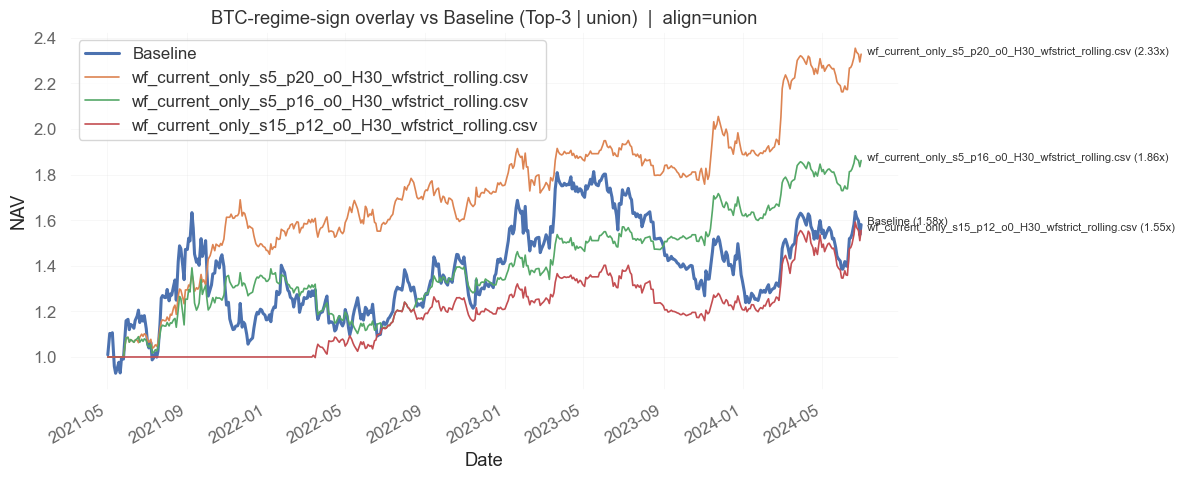

In [55]:

def plot_topn_nav_vs_baseline(results: pd.DataFrame,
                              rets_map: dict[str, pd.Series],
                              ret_base: pd.Series,
                              topn: int = 5,
                              align: str = "overlap",   # "overlap" or "union"
                              title: str = "Top-N params vs Baseline (NAV)",
                              annotate_last: bool = True):
    """
    Plot NAV curves of the Top-N strategies (by Sharpe) against the Baseline.

    Parameters
    ----------
    results : pd.DataFrame
        Output table from batch evaluation (e.g., batch_eval_*). Must include
        at least ['signal_file', 'Sharpe Ratio'].
    rets_map : dict[str, pd.Series]
        Mapping from signal filename to its daily return series.
    ret_base : pd.Series
        Baseline daily return series.
    topn : int, optional
        Number of top strategies to plot, by descending Sharpe, by default 5.
    align : {"overlap", "union"}, optional
        Alignment method for the time index:
        - "overlap": intersect all indices (only shared dates).
        - "union": union of all dates; missing returns are filled with 0.
    title : str, optional
        Plot title.
    annotate_last : bool, optional
        Whether to annotate the last NAV value (as “x.xx×”) for each curve.

    Notes
    -----
    - NAV is computed as cumulative product of (1 + daily return).
    - Baseline is plotted with a thicker line for visibility.
    """
    # --- pick Top-N by Sharpe ---
    df = results.dropna(subset=["Sharpe Ratio"]).sort_values("Sharpe Ratio", ascending=False)
    pick = []
    for name in df["signal_file"]:
        if name in rets_map:
            pick.append(name)
        if len(pick) >= topn:
            break
    if not pick:
        raise ValueError("No usable Top-N results (no matching series in `rets_map`).")

    # --- collect and align series ---
    series_list = [ret_base.rename("Baseline")] + [rets_map[n].rename(n) for n in pick]

    if align == "overlap":
        idx = series_list[0].index
        for s in series_list[1:]:
            idx = idx.intersection(s.index)
        aligned = [s.reindex(idx) for s in series_list]
    elif align == "union":
        idx = sorted(set().union(*[s.index for s in series_list]))
        aligned = [s.reindex(idx).fillna(0.0) for s in series_list]
    else:
        raise ValueError("`align` must be 'overlap' or 'union'.")

    # --- compute NAVs ---
    navs = [(1.0 + s).cumprod() for s in aligned]
    nav = pd.concat(navs, axis=1)
    nav.columns = [ser.name for ser in aligned]

    # --- plot ---
    plt.figure(figsize=(12, 5))
    # Make Baseline thicker
    nav["Baseline"].plot(linewidth=2.2, label="Baseline")
    for col in nav.columns[1:]:
        nav[col].plot(linewidth=1.2, label=col)

    if annotate_last:
        last = nav.iloc[-1]
        for col in nav.columns:
            y = last[col]
            plt.text(nav.index[-1], y, f"  {col} ({y:.2f}x)", fontsize=8)

    plt.title(title + (f"  |  align={align}" if align else ""))
    plt.ylabel("NAV")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


# `ret_base` is the Baseline return series; `results` and `rets_map` come from batch_eval_btc_regime_sign
plot_topn_nav_vs_baseline(results, rets_map, ret_base,
                          topn=3, align="union",
                          title="BTC-regime-sign overlay vs Baseline (Top-3 | union)")


In [56]:
import numpy as np
import pandas as pd
from pathlib import Path
import quantstats as qs

all_returns = pd.concat(
    [ret_base.rename("Baseline")] + [s.rename(k) for k, s in rets_map.items()],
    axis=1
).sort_index()
# 你的 returns 表：索引是日期，列名含 "Baseline" 和若干策略列
# 注意：quantstats 期望“简单收益”（2% = 0.02），不是 log return
df = all_returns.copy()                   # <-- 换成你的 DataFrame 变量名
#df.index = pd.to_datetime(df.index).tz_localize(None).sort_index()

# 如果你之前用的是“对数收益”，请先转回简单收益（否则 comp/NAV 会不对）
# df = df.apply(np.expm1)  # ← 只有在你确认是log return时再打开

# 1) 对齐到完整“日”日历，并把缺失日填 0（表示那天不交易）
#idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
#df = df.reindex(idx).fillna(0.0)

# 2) 导出给老师（Excel/CSV，数值是 fraction，比如 0.02）
out_dir = Path("qs_reports"); out_dir.mkdir(exist_ok=True)
df.to_excel(out_dir / "daily_returns.xlsx", float_format="%.6f")
df.to_csv  (out_dir / "daily_returns.csv",  float_format="%.6f")
print("✓ saved:", out_dir / "daily_returns.xlsx")

# 3) 选一个策略，快速生成 vs Baseline 的 HTML 报告
qs.extend_pandas()  # 有些版本需要
bench = df["Baseline"]
strategy_col = [c for c in df.columns if c != "Baseline"][0]   # 就拿第一条策略演示
qs.reports.html(
    df[strategy_col],
    benchmark=bench,
    output=str(out_dir / f"{strategy_col}_vs_baseline.html"),
    title=f"{strategy_col} vs Baseline",
    periods_per_year=365,       # 加密日频建议 365；股票用 252
    figfmt="png",
    match_dates=True
)
print("✓ report:", out_dir / f"{strategy_col}_vs_baseline.html")


✓ saved: qs_reports/daily_returns.xlsx


/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/quantstats/stats.py:1365: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = _utils._prepare_returns(returns, rf).resample(resolution).sum()
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_16483/2846217953.py:34: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  y = s.resample("A").apply(qs.stats.comp) if compounded else s.resample("A").sum()


✓ report: qs_reports/wf_current_only_s10_p12_o0_H30_wfstrict_rolling.csv_vs_baseline.html


In [58]:
import numpy as np
import pandas as pd
from pathlib import Path
import quantstats as qs

# ========= 0) 准备数据 =========
df = all_returns.copy()  # ← 换成你的 DataFrame
# 索引统一为无时区、已排序
df.index = pd.to_datetime(df.index, utc=True).tz_convert(None)
df = df.sort_index()

# 如果你之前用对数收益，请先转回简单收益（只在确认是 log return 时打开）
# df = df.apply(np.expm1)

# （可选）补全完整日历并把缺失日填 0：只在你明确“休市=0收益”时才使用
idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
df = df.reindex(idx).fillna(0.0)

out_dir = Path("qs_reports"); out_dir.mkdir(exist_ok=True)
df.to_excel(out_dir / "daily_returns.xlsx", float_format="%.6f")
df.to_csv  (out_dir / "daily_returns.csv",  float_format="%.6f")
print("✓ saved:", out_dir / "daily_returns.xlsx")

# ========= 1) 指标函数（纯 pandas/numpy，独立于 quantstats 版本）=========
PPY = 365  # 加密/自然日建议 365；若是股票交易日，可改为 252

def _align(a: pd.Series, b: pd.Series):
    return a.dropna().align(b.dropna(), join="inner")

def _cagr(r: pd.Series, ppy=PPY):
    n = r.shape[0]
    if n == 0: return np.nan
    total = (1.0 + r).prod()
    # 年数 = n / ppy
    return total**(ppy / n) - 1.0

def _ann_mean(r: pd.Series, ppy=PPY):
    return r.mean() * ppy

def _ann_vol(r: pd.Series, ppy=PPY):
    return r.std(ddof=1) * np.sqrt(ppy)

def _downside_dev(r: pd.Series):
    neg = r[r < 0]
    return 0.0 if neg.empty else neg.std(ddof=1)

def _sharpe(r: pd.Series, ppy=PPY, rf=0.0):
    # rf 按年，折算到日：rf/ppy
    ex = r - rf / ppy
    sd = ex.std(ddof=1)
    return np.nan if sd == 0 or np.isnan(sd) else ex.mean() / sd * np.sqrt(ppy)

def _sortino(r: pd.Series, ppy=PPY, rf=0.0):
    ex = r - rf / ppy
    dd = _downside_dev(ex)
    return np.nan if dd == 0 or np.isnan(dd) else ex.mean() / dd * np.sqrt(ppy)

def _max_dd(r: pd.Series):
    nav = (1.0 + r).cumprod()
    dd = nav / nav.cummax() - 1.0
    return dd.min() if not dd.empty else np.nan

def _calmar(r: pd.Series, ppy=PPY):
    cagr = _cagr(r, ppy)
    mdd = _max_dd(r)
    return np.nan if (mdd is None or mdd == 0 or np.isnan(mdd)) else cagr / abs(mdd)

def _win_rate(r: pd.Series):
    return (r > 0).mean() if len(r) else np.nan

def _beta_alpha_ir(s: pd.Series, b: pd.Series, ppy=PPY, rf=0.0):
    s, b = _align(s, b)
    if len(s) == 0: 
        return np.nan, np.nan, np.nan, np.nan
    var_b = b.var(ddof=1)
    beta = np.nan if var_b == 0 or np.isnan(var_b) else s.cov(b) / var_b
    # Jensen's alpha（年化）
    alpha = (s.mean() - rf/ppy) - (beta * (b.mean() - rf/ppy))
    alpha = alpha * ppy
    # Tracking Error（年化）
    diff = s - b
    te = diff.std(ddof=1) * np.sqrt(ppy)
    # Information Ratio（年化）
    ir = np.nan if te == 0 or np.isnan(te) else (diff.mean() * ppy) / te
    return beta, alpha, ir, te

def summarize_one(name: str, s: pd.Series, bench: pd.Series, ppy=PPY, rf=0.0):
    s = s.dropna()
    if s.empty:
        return {
            "Strategy": name, "Obs": 0, "Total Return": np.nan, "CAGR": np.nan,
            "Sharpe": np.nan, "Sortino": np.nan, "Vol (ann)": np.nan,
            "MaxDD": np.nan, "Calmar": np.nan, "WinRate": np.nan,
            "Beta vs Base": np.nan, "Alpha (ann)": np.nan,
            "InfoRatio": np.nan, "TrackErr (ann)": np.nan,
        }
    beta, alpha, ir, te = _beta_alpha_ir(s, bench, ppy=ppy, rf=rf)
    return {
        "Strategy": name,
        "Obs": len(s),
        "Total Return": (1 + s).prod() - 1.0,
        "CAGR": _cagr(s, ppy),
        "Sharpe": _sharpe(s, ppy, rf),
        "Sortino": _sortino(s, ppy, rf),
        "Vol (ann)": _ann_vol(s, ppy),
        "MaxDD": _max_dd(s),
        "Calmar": _calmar(s, ppy),
        "WinRate": _win_rate(s),
        "Beta vs Base": beta,
        "Alpha (ann)": alpha,
        "InfoRatio": ir,
        "TrackErr (ann)": te,
    }

# ========= 2) 生成全部 HTML 报告 + 汇总表 =========
qs.extend_pandas()  # 某些版本需要
bench = df["Baseline"]
strategies = [c for c in df.columns if c != "Baseline"]

summary_rows = []

# 也给 Baseline 自己算一行
summary_rows.append(summarize_one("Baseline", bench, bench))

for col in strategies:
    s = df[col]
    # 先生成报告（用 quantstats）
    html_path = out_dir / f"{col}_vs_baseline.html"
    qs.reports.html(
        s, 
        benchmark=bench, 
        output=str(html_path),
        title=f"{col} vs Baseline",
        periods_per_year=PPY,
        figfmt="png",
        match_dates=True
    )
    print("✓ report:", html_path)

    # 再把主要指标塞进汇总
    row = summarize_one(col, s, bench, ppy=PPY)
    row["Report"] = str(html_path.name)
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("Strategy")

# （可选）再加上“相对 Baseline 的差值列”，便于比较
base = summary.loc["Baseline"]
for k in ["CAGR", "Sharpe", "Sortino", "Vol (ann)", "MaxDD", "Calmar", "WinRate", "InfoRatio"]:
    if k in summary.columns:
        summary[f"{k}-ΔvsBase"] = summary[k] - (base[k] if pd.notna(base[k]) else np.nan)

# 导出汇总
summary_path_xlsx = out_dir / "summary_metrics.xlsx"
summary_path_csv  = out_dir / "summary_metrics.csv"
with pd.ExcelWriter(summary_path_xlsx) as w:
    summary.to_excel(w, sheet_name="metrics", float_format="%.6f")
summary.to_csv(summary_path_csv, float_format="%.6f")
print("✓ metrics:", summary_path_xlsx)

# 打印按 Sharpe 排名前 5（排除 Baseline）
top5 = summary.drop(index="Baseline", errors="ignore").sort_values("Sharpe", ascending=False).head(5)
print("\nTop-5 by Sharpe:\n", top5[["CAGR","Sharpe","Sortino","MaxDD","Calmar","InfoRatio"]])


✓ saved: qs_reports/daily_returns.xlsx


/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/quantstats/stats.py:1365: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = _utils._prepare_returns(returns, rf).resample(resolution).sum()
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_16483/2846217953.py:34: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  y = s.resample("A").apply(qs.stats.comp) if compounded else s.resample("A").sum()


✓ report: qs_reports/wf_current_only_s10_p12_o0_H30_wfstrict_rolling.csv_vs_baseline.html


/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/quantstats/stats.py:1365: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = _utils._prepare_returns(returns, rf).resample(resolution).sum()
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_16483/2846217953.py:34: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  y = s.resample("A").apply(qs.stats.comp) if compounded else s.resample("A").sum()


✓ report: qs_reports/wf_current_only_s10_p16_o0_H30_wfstrict_rolling.csv_vs_baseline.html


...

✓ report: qs_reports/wf_current_only_s8_p16_o0_H30_wfstrict_rolling.csv_vs_baseline.html


/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/quantstats/stats.py:1365: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = _utils._prepare_returns(returns, rf).resample(resolution).sum()
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_16483/2846217953.py:34: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  y = s.resample("A").apply(qs.stats.comp) if compounded else s.resample("A").sum()


✓ report: qs_reports/wf_current_only_s8_p20_o0_H30_wfstrict_rolling.csv_vs_baseline.html


/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/quantstats/stats.py:1365: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = _utils._prepare_returns(returns, rf).resample(resolution).sum()
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_16483/2846217953.py:34: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  y = s.resample("A").apply(qs.stats.comp) if compounded else s.resample("A").sum()


✓ report: qs_reports/wf_current_only_s8_p8_o0_H30_wfstrict_rolling.csv_vs_baseline.html
✓ metrics: qs_reports/summary_metrics.xlsx

Top-5 by Sharpe:
                                                         CAGR    Sharpe  \
Strategy                                                                 
wf_current_only_s5_p20_o0_H30_wfstrict_rolling.csv  0.305753  1.443833   
wf_current_only_s5_p16_o0_H30_wfstrict_rolling.csv  0.216773  1.006495   
wf_current_only_s15_p12_o0_H30_wfstrict_rolling...  0.149568  0.892451   
wf_current_only_s15_p16_o0_H30_wfstrict_rolling...  0.154017  0.853353   
wf_current_only_s5_p8_o0_H30_wfstrict_rolling.csv   0.161441  0.816380   

                                                     Sortino     MaxDD  \
Strategy                                                                 
wf_current_only_s5_p20_o0_H30_wfstrict_rolling.csv  1.565549 -0.141488   
wf_current_only_s5_p16_o0_H30_wfstrict_rolling.csv  0.996321 -0.207176   
wf_current_only_s15_p12_o0_H30_wfst

In [77]:

r_base = backtest_lead_lag_hedge(
    prices=prices,
    lead_lag_matrix_rolling=lead_lag_sig,
    quantile=0.3,
    min_names=2,
    use_log_returns=True,
)
eval_base_full = evaluate_strategy_calendar(r_base, calendar_index=price_calendar, ann_factor=365)
print("BASELINE (full):", eval_base_full)


best_name = results.iloc[0]["signal_file"]
r_reg  = rets_map[best_name]                # overlay 的最终收益序列（已应用是否翻转）
eval_reg_full = evaluate_strategy_calendar(r_reg, calendar_index=price_calendar, ann_factor=365)
print("REGIME (full):", eval_reg_full)


train_end_ts = pd.to_datetime("2023-12-31")
cal_train = price_calendar[price_calendar <= train_end_ts]
cal_oos   = price_calendar[price_calendar >  train_end_ts]

print("BASELINE (train):", evaluate_strategy_calendar(r_base.loc[:train_end_ts], cal_train, ann_factor=365))
print("REGIME   (train):", evaluate_strategy_calendar(r_reg .loc[:train_end_ts], cal_train, ann_factor=365))
print("BASELINE (oos):  ", evaluate_strategy_calendar(r_base.loc[train_end_ts+pd.Timedelta(days=1):], cal_oos, ann_factor=365))
print("REGIME   (oos):  ", evaluate_strategy_calendar(r_reg .loc[train_end_ts+pd.Timedelta(days=1):], cal_oos, ann_factor=365))

BASELINE (full): {'Annual Return (%)': 7.591766928698629, 'Sharpe Ratio': 0.4015174627395278, 'Volatility (%)': 27.79902434484893, 'Max Drawdown (%)': -28.09457919822156, 'Calendar Days': 1144, 'Active Days': 496, 'Active Ratio (%)': 43.35664335664335, 'Final NAV': 1.2577761246683732}
REGIME (full): {'Annual Return (%)': 30.098467934004102, 'Sharpe Ratio': 1.4244258365590086, 'Volatility (%)': 19.850756086274266, 'Max Drawdown (%)': -14.148817585563744, 'Calendar Days': 1144, 'Active Days': 476, 'Active Ratio (%)': 41.60839160839161, 'Final NAV': 2.2811676069150053}
BASELINE (train): {'Annual Return (%)': 10.432987850179787, 'Sharpe Ratio': 0.4870276450173481, 'Volatility (%)': 28.922152444343073, 'Max Drawdown (%)': -28.09457919822156, 'Calendar Days': 975, 'Active Days': 418, 'Active Ratio (%)': 42.87179487179487, 'Final NAV': 1.303547891843854}
REGIME   (train): {'Annual Return (%)': 26.86842716277478, 'Sharpe Ratio': 1.2790174280803943, 'Volatility (%)': 20.197660607832933, 'Max Dr

In [55]:
btc_col = "BTC"  # 和回测时保持一致

def extract_btc_signal(ds, btc_col="BTC"):
    import pandas as pd
    # Series：直接用
    if isinstance(ds, pd.Series):
        return pd.to_numeric(ds, errors="coerce")
    # DataFrame：优先取 btc_col，其次常见别名；单列则取首列
    if isinstance(ds, pd.DataFrame):
        for c in [btc_col, "BTC-USD", "BTCUSDT", "XBTUSD", "XBT", "BTC"]:
            if c in ds.columns:
                return pd.to_numeric(ds[c], errors="coerce")
        if ds.shape[1] == 1:
            return pd.to_numeric(ds.iloc[:, 0], errors="coerce")
        raise KeyError(f"未在信号文件中找到 BTC 列；可改用 btc_col=...，现有列：{list(ds.columns)[:10]}")
    raise TypeError(f"不支持的类型：{type(ds)}")

# 读取“最佳”的那个信号文件，并提取 BTC 方向信号
ds = read_daily_dir_signal_csv(Path(signal_dir) / best_name)
sig = extract_btc_signal(ds, btc_col=btc_col)

# 对齐到“下一交易日”
sig_nextday = sig.shift(1).reindex(r_reg.index)

# 与 Baseline 对齐
r_base_aligned = r_base.reindex(r_reg.index)

# 中性日：信号==0
mask_neutral = (sig_nextday == 0)

# 中性日差值应≈0（neutral_mode="baseline" 的契约）
diff_neutral = (r_reg[mask_neutral] - r_base_aligned[mask_neutral]).dropna()
print("Neutral-days mean abs diff:", float(diff_neutral.abs().mean()))
print("Neutral-days count:", int(mask_neutral.sum()))


Neutral-days mean abs diff: 0.009621176141673375
Neutral-days count: 50


In [56]:
delta = (r_reg.reindex(price_calendar).fillna(0) -
         r_base.reindex(price_calendar).fillna(0))
eval_delta = evaluate_strategy_calendar(delta, calendar_index=price_calendar, ann_factor=365)
print("Overlay incremental (REGIME - BASELINE):", eval_delta)

Overlay incremental (REGIME - BASELINE): {'Annual Return (%)': 15.920958885661518, 'Sharpe Ratio': 0.8012726056767535, 'Volatility (%)': 21.23757403140977, 'Max Drawdown (%)': -24.51744766449655, 'Calendar Days': 1144, 'Active Days': 1144, 'Active Ratio (%)': 100.0, 'Final NAV': 1.588910440746565}


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Utilities ----------

def _align_two(a: pd.Series, b: pd.Series, how: str = "union"):
    """Align two return series on either the union (fill missing with 0) or overlap (intersection)."""
    if how == "union":
        idx = sorted(set(a.index).union(b.index))
        return a.reindex(idx).fillna(0.0), b.reindex(idx).fillna(0.0)
    elif how == "overlap":
        idx = a.index.intersection(b.index)
        return a.reindex(idx), b.reindex(idx)
    else:
        raise ValueError("how must be 'union' or 'overlap'")

def _to_nav(r: pd.Series) -> pd.Series:
    """Turn daily returns into NAV."""
    return (1.0 + r).cumprod()

# ---------- 1) Underwater (Drawdown) Comparison ----------

def plot_underwater_comparison(ret_base: pd.Series,
                               ret_overlay: pd.Series,
                               align: str = "union",
                               title: str = "Underwater (Drawdown) — Overlay vs Baseline"):
    """Compare drawdowns to show how much risk the overlay removes."""
    a, b = _align_two(ret_base, ret_overlay, how=align)
    nav_a, nav_b = _to_nav(a), _to_nav(b)
    dd_a = nav_a / nav_a.cummax() - 1.0
    dd_b = nav_b / nav_b.cummax() - 1.0

    plt.figure(figsize=(12, 5))
    dd_a.plot(linewidth=1.6, label="Baseline")
    dd_b.plot(linewidth=1.6, label="Overlay")
    plt.axhline(0, linewidth=1)
    plt.title(title + f"  |  align={align}")
    plt.ylabel("Drawdown")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ---------- 2) Rolling Sharpe & Rolling Volatility ----------

def plot_rolling_sharpe(ret_base: pd.Series,
                        ret_overlay: pd.Series,
                        window: int = 90,
                        ann_factor: int = 365,
                        align: str = "union",
                        title: str = "Rolling Sharpe (annualized)"):
    """Who is more stable over time."""
    a, b = _align_two(ret_base, ret_overlay, how=align)
    def rsharpe(x):
        m, s = x.mean(), x.std(ddof=0)
        return np.nan if s == 0 else (m / s) * np.sqrt(ann_factor)
    rs_a = a.rolling(window).apply(lambda x: rsharpe(pd.Series(x)), raw=False)
    rs_b = b.rolling(window).apply(lambda x: rsharpe(pd.Series(x)), raw=False)

    plt.figure(figsize=(12, 5))
    rs_a.plot(linewidth=1.6, label="Baseline")
    rs_b.plot(linewidth=1.6, label="Overlay")
    plt.title(f"{title}  (window={window})  |  align={align}")
    plt.ylabel("Sharpe")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def plot_rolling_vol(ret_base: pd.Series,
                     ret_overlay: pd.Series,
                     window: int = 90,
                     ann_factor: int = 365,
                     align: str = "union",
                     title: str = "Rolling Volatility (annualized)"):
    """Who runs “quieter” over time."""
    a, b = _align_two(ret_base, ret_overlay, how=align)
    rv_a = a.rolling(window).std(ddof=0) * np.sqrt(ann_factor)
    rv_b = b.rolling(window).std(ddof=0) * np.sqrt(ann_factor)

    plt.figure(figsize=(12, 5))
    rv_a.plot(linewidth=1.6, label="Baseline")
    rv_b.plot(linewidth=1.6, label="Overlay")
    plt.title(f"{title}  (window={window})  |  align={align}")
    plt.ylabel("Vol (%)")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ---------- 3) Incremental NAV (Overlay − Baseline) ----------

def plot_incremental_nav(ret_base: pd.Series,
                         ret_overlay: pd.Series,
                         align: str = "union",
                         title: str = "Incremental NAV (Overlay − Baseline)"):
    """Pure value-add curve; rising line means overlay keeps adding alpha versus baseline."""
    a, b = _align_two(ret_base, ret_overlay, how=align)
    inc = b - a
    inc_nav = _to_nav(inc)

    plt.figure(figsize=(12, 5))
    inc_nav.plot(linewidth=1.8)
    plt.title(title + f"  |  align={align}")
    plt.ylabel("Incremental NAV")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------- 4) Return Distribution & Tails ----------

def plot_return_hist(ret_base: pd.Series,
                     ret_overlay: pd.Series,
                     bins: int = 50,
                     align: str = "overlap",
                     title: str = "Daily Return Distribution"):
    """Assess tail trimming / right-tail boost."""
    a, b = _align_two(ret_base, ret_overlay, how=align)
    plt.figure(figsize=(12, 5))
    plt.hist(a.dropna().values, bins=bins, alpha=0.5, label="Baseline")
    plt.hist(b.dropna().values, bins=bins, alpha=0.5, label="Overlay")
    plt.title(title + f"  |  align={align}")
    plt.xlabel("Daily return")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ---------- 5) Scatter: Overlay vs Baseline (per day) ----------

def plot_scatter_overlay_vs_base(ret_base: pd.Series,
                                 ret_overlay: pd.Series,
                                 align: str = "overlap",
                                 title: str = "Overlay vs Baseline — daily returns"):
    """Show correlation and slope; points below y=x are days when overlay underperforms."""
    a, b = _align_two(ret_base, ret_overlay, how=align)
    x, y = a.values, b.values
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=12, alpha=0.6)
    # 45-degree line
    lim = [min(x.min(), y.min()), max(x.max(), y.max())]
    plt.plot(lim, lim, linewidth=1)
    # Simple regression line
    if len(x) >= 2:
        k, c = np.polyfit(x, y, 1)
        xs = np.linspace(lim[0], lim[1], 100)
        plt.plot(xs, k * xs + c, linewidth=1)
    plt.title(title + f"  |  align={align}")
    plt.xlabel("Baseline daily return")
    plt.ylabel("Overlay daily return")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------- 6) Regime Attribution & Time-in-Market ----------

def plot_regime_attribution(ret_base: pd.Series,
                            ret_overlay: pd.Series,
                            signal_at_exec: pd.Series,
                            align: str = "overlap",
                            title: str = "Regime Attribution (sum of daily returns)"):
    """
    Attribute P&L to regimes s ∈ {-1, 0, +1} based on the EXECUTION-DAY signal.
    Shows how much each regime contributes for baseline vs overlay.
    """
    # Align all on overlap; we assume signal_at_exec is already shifted to execution day
    a, b = _align_two(ret_base, ret_overlay, how=align)
    s = signal_at_exec.reindex(a.index).fillna(0)

    buckets = [-1, 0, 1]
    base_contrib, over_contrib = [], []
    for val in buckets:
        mask = (s == val)
        base_contrib.append(a[mask].sum())
        over_contrib.append(b[mask].sum())

    x = np.arange(len(buckets))
    width = 0.35
    plt.figure(figsize=(10, 4))
    plt.bar(x - width/2, base_contrib, width, label="Baseline")
    plt.bar(x + width/2, over_contrib, width, label="Overlay")
    plt.xticks(x, ["-1", "0", "+1"])
    plt.title(title + f"  |  align={align}")
    plt.xlabel("Regime (s)")
    plt.ylabel("Sum of daily returns")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def plot_time_in_market(signal_at_exec: pd.Series,
                        window: int = 60,
                        title: str = "Rolling Time-in-Market (share of non-zero regimes)"):
    """Rolling share of days with |signal| > 0; proxy for capital utilization."""
    s = signal_at_exec.copy().astype(float)
    active = (s.abs() > 0).astype(float)
    tim = active.rolling(window).mean()

    plt.figure(figsize=(12, 4))
    tim.plot(linewidth=1.6)
    plt.title(f"{title}  (window={window})")
    plt.ylabel("Share")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------- 7) Monthly Returns (side-by-side bars) ----------

def plot_monthly_returns_bars(ret_base: pd.Series,
                              ret_overlay: pd.Series,
                              align: str = "union",
                              title: str = "Monthly Returns — Overlay vs Baseline"):
    """Compare consistency across months."""
    a, b = _align_two(ret_base, ret_overlay, how=align)
    def monthly_ret(x: pd.Series):
        return (1.0 + x).prod() - 1.0
    ma = a.resample("M").apply(monthly_ret)
    mb = b.resample("M").apply(monthly_ret)

    idx = ma.index
    plt.figure(figsize=(12, 5))
    w = 10  # width in days to separate bars visually
    plt.bar(idx - pd.Timedelta(days=w), ma.values, width=15, label="Baseline")
    plt.bar(idx + pd.Timedelta(days=w), mb.values, width=15, label="Overlay")
    plt.title(title + f"  |  align={align}")
    plt.ylabel("Monthly return")
    plt.xlabel("Month")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


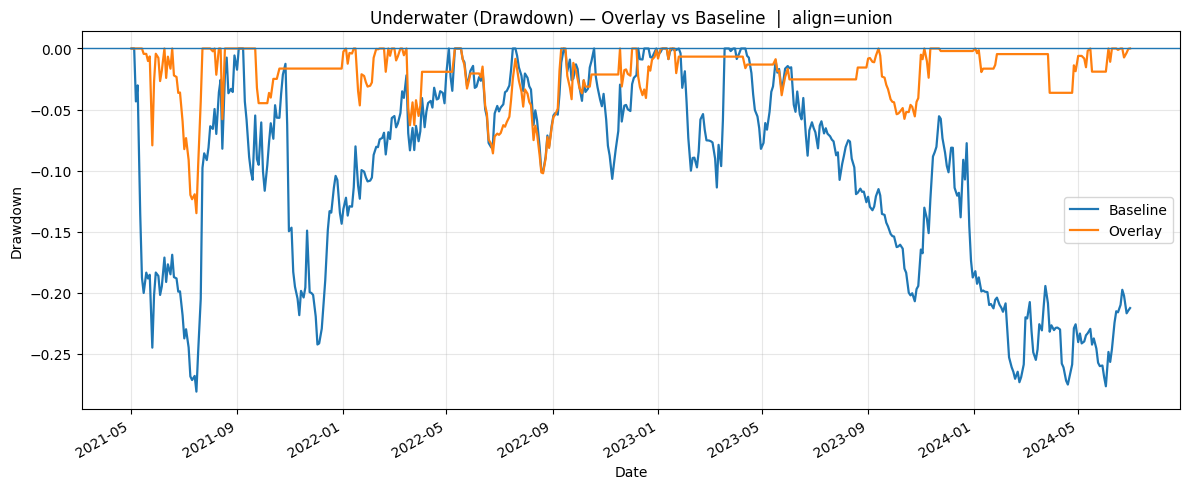

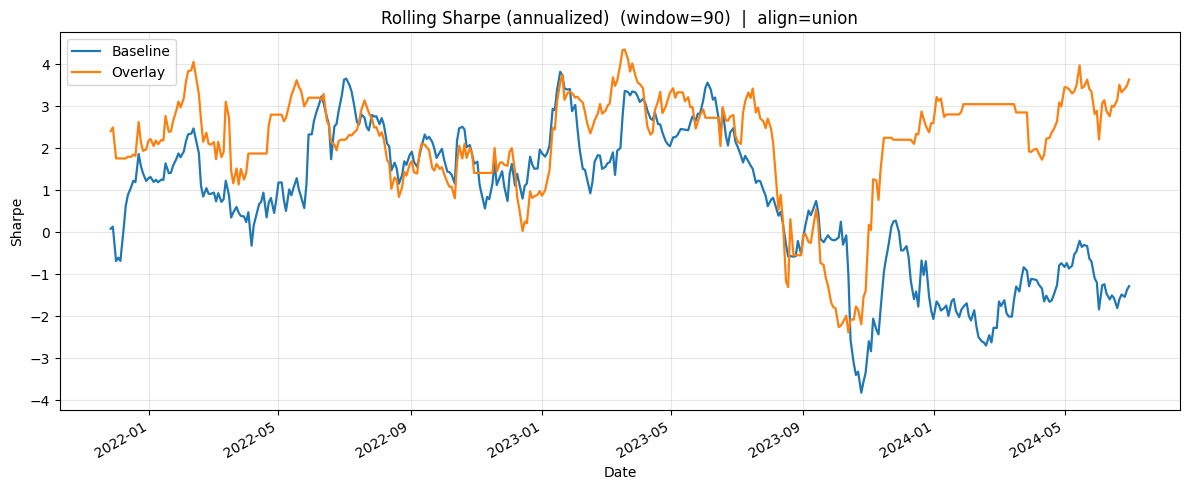

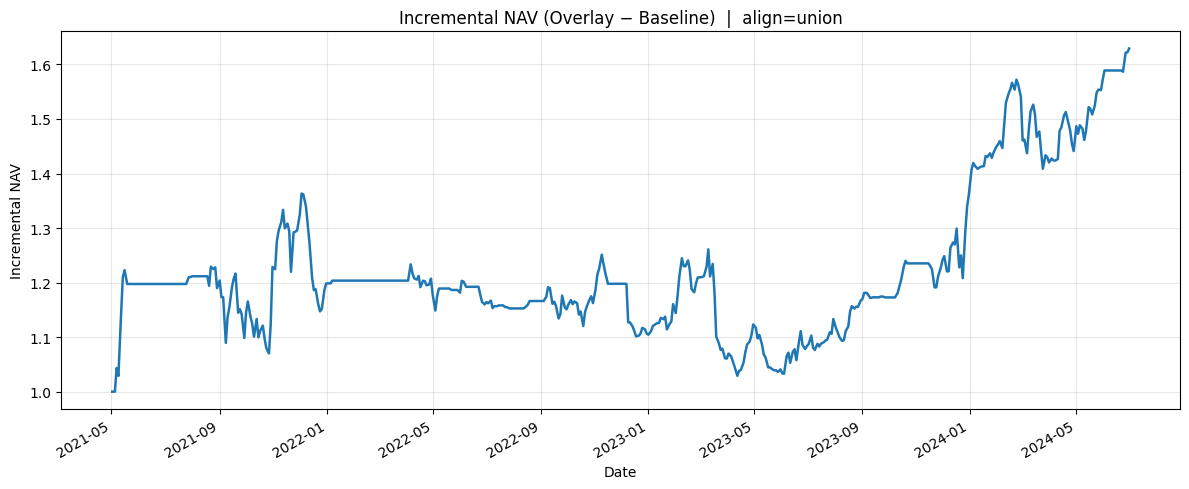

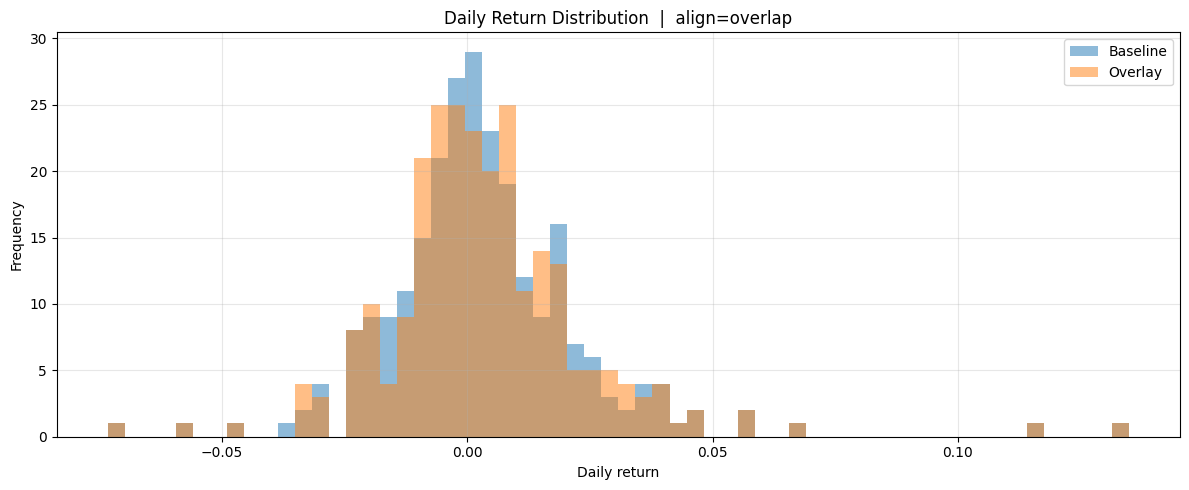

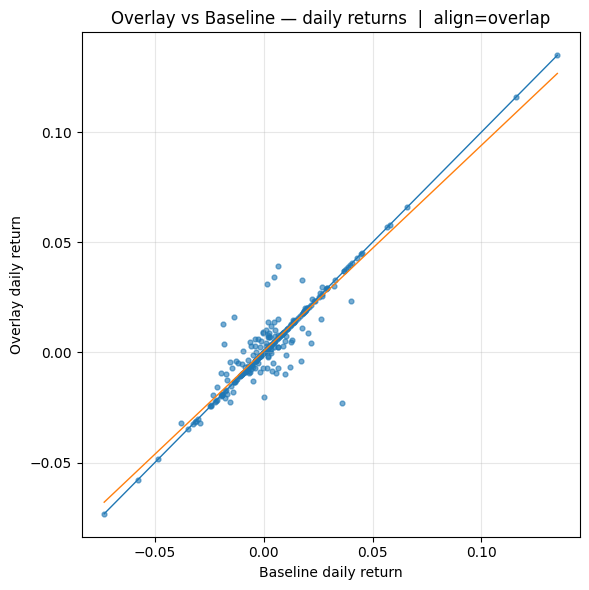

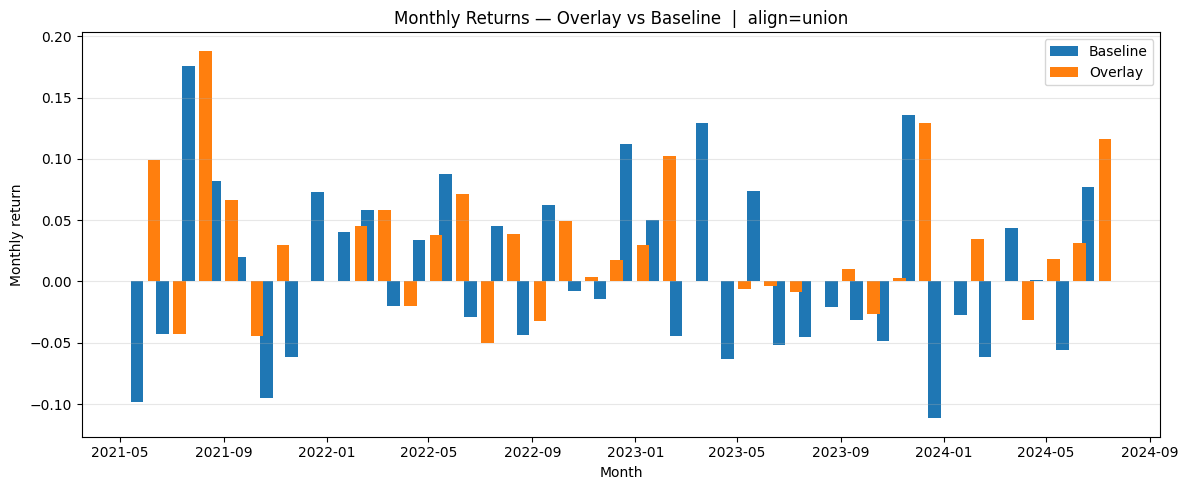

In [80]:
# choose one overlay series from your `rets_map` (e.g., best by Sharpe)
best_name = results.sort_values("Sharpe Ratio", ascending=False).iloc[0]["signal_file"]
ret_overlay = rets_map[best_name]

# (optional) execution-day regime signal for attribution / time-in-market
# sig_exec = your_direction_signal.shift(1).reindex(ret_overlay.index)

plot_underwater_comparison(ret_base, ret_overlay, align="union")
plot_rolling_sharpe(ret_base, ret_overlay, window=90, ann_factor=365, align="union")
plot_incremental_nav(ret_base, ret_overlay, align="union")
plot_return_hist(ret_base, ret_overlay, bins=60, align="overlap")
plot_scatter_overlay_vs_base(ret_base, ret_overlay, align="overlap")
# plot_regime_attribution(ret_base, ret_overlay, sig_exec, align="overlap")
# plot_time_in_market(sig_exec, window=60)
plot_monthly_returns_bars(ret_base, ret_overlay, align="union")


In [69]:
import re, numpy as np, pandas as pd

# e.g. daily_dir_s5_p16_o0_H30_proto_k5.csv
_PAT = re.compile(
    r"s(?P<steps>\d+)_p(?P<paths>\d+)_o(?P<offset>-?\d+)"
    r"(?:_H(?P<H>\d+))?(?:_proto)?(?:_k(?P<k>\d+))?"
)

def _extract_params(name: str) -> dict:
    m = _PAT.search(name)
    if not m:
        return dict(steps=np.nan, paths=np.nan, offset=np.nan, H=np.nan, k=np.nan)
    out = {k: (int(v) if v is not None else np.nan) for k, v in m.groupdict().items()}
    return out

def build_comparison_table(results: pd.DataFrame, base_stats: dict) -> pd.DataFrame:
    """Attach params & compute deltas vs Baseline."""
    df = results.copy()
    params = df["signal_file"].map(_extract_params).apply(pd.Series)
    df = pd.concat([df, params], axis=1)

    # Baseline metrics（统一口径）
    b_sharpe = base_stats["Sharpe Ratio"]
    b_ann    = base_stats["Annual Return (%)"]
    b_vol    = base_stats["Volatility (%)"]
    b_mdd    = base_stats["Max Drawdown (%)"]
    b_nav    = base_stats["Final NAV"]

    # Deltas（单位：pp=百分比点；MDD/Vol 是“降低为正”）
    df["ΔSharpe"]        = df["Sharpe Ratio"] - b_sharpe
    df["ΔAnnRet (pp)"]   = df["Annual Return (%)"] - b_ann
    df["MDD reduction"]  = b_mdd - df["Max Drawdown (%)"]     # 正数=回撤更小
    df["Vol reduction"]  = b_vol - df["Volatility (%)"]       # 正数=波动更低
    df["NAV ratio (×)"]  = df["Final NAV"] / b_nav

    # 排序 & 只保留关键列
    keep = ["signal_file","steps","paths","H","k","flipped",
            "Sharpe Ratio","Annual Return (%)","Volatility (%)","Max Drawdown (%)","Final NAV",
            "ΔSharpe","ΔAnnRet (pp)","MDD reduction","Vol reduction","NAV ratio (×)"]
    df = df[keep].sort_values(["ΔSharpe","MDD reduction"], ascending=False)
    return df
# 你已有 baseline 统计：stats_base_cal
cmp_df = build_comparison_table(results, stats_base_cal)
cmp_df.head(10)


,signal_file,steps,paths,H,k,flipped,Sharpe Ratio,Annual Return (%),Volatility (%),Max Drawdown (%),Final NAV,ΔSharpe,ΔAnnRet (pp),MDD reduction,Vol reduction,NAV ratio (×)
9,daily_dir_s5_p16_o0_H30_proto_k5.csv,5,16,30,5,False,1.470370,30.183291,19.164481,-13.483976,2.285832,1.068853,22.591524,-1.461060e+01,8.634543,1.817360
0,daily_dir_s10_p12_o0_H30_proto_k5.csv,10,12,30,5,False,1.412556,31.420085,20.864494,-14.955801,2.354589,1.011039,23.828319,-1.313878e+01,6.934530,1.872026
13,daily_dir_s8_p16_o0_H30_proto_k5.csv,8,16,30,5,False,0.879859,16.959287,20.081559,-17.527552,1.633946,0.478341,9.367521,-1.056703e+01,7.717465,1.299075
7,daily_dir_s15_p8_o0_H30_proto_k5.csv,15,8,30,5,False,0.825323,16.083718,20.618915,-24.425611,1.595913,0.423806,8.491951,-3.668968e+00,7.180109,1.268837
10,daily_dir_s5_p20_o0_H30_proto_k5.csv,5,20,30,5,False,0.794216,14.827963,19.868123,-28.094579,1.542425,0.392699,7.236196,1.065814e-14,7.930901,1.226312
14,daily_dir_s8_p20_o0_H30_proto_k5.csv,8,20,30,5,False,0.696689,13.690703,21.803146,-22.873614,1.495050,0.295172,6.098936,-5.220965e+00,5.995878,1.188646
12,daily_dir_s8_p12_o0_H30_proto_k5.csv,8,12,30,5,False,0.676924,13.738519,22.832287,-26.736131,1.497022,0.275406,6.146752,-1.358448e+00,4.966737,1.190213
2,daily_dir_s10_p20_o0_H30_proto_k5.csv,10,20,30,5,False,0.478517,9.062130,24.138683,-29.569413,1.312440,0.076999,1.470363,1.474833e+00,3.660342,1.043461
3,daily_dir_s10_p8_o0_H30_proto_k5.csv,10,8,30,5,True,0.461941,8.421289,23.532616,-31.204177,1.288421,0.060424,0.829522,3.109598e+00,4.266409,1.024364
1,daily_dir_s10_p16_o0_H30_proto_k5.csv,10,16,30,5,False,0.398227,7.070881,24.781738,-25.467499,1.238789,-0.003290,-0.520886,-2.627081e+00,3.017286,0.984904


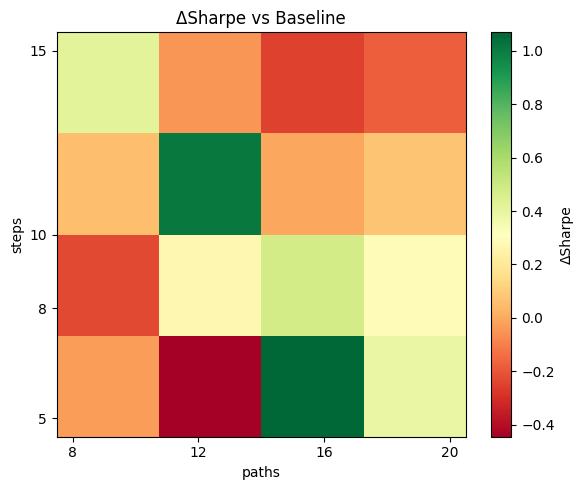

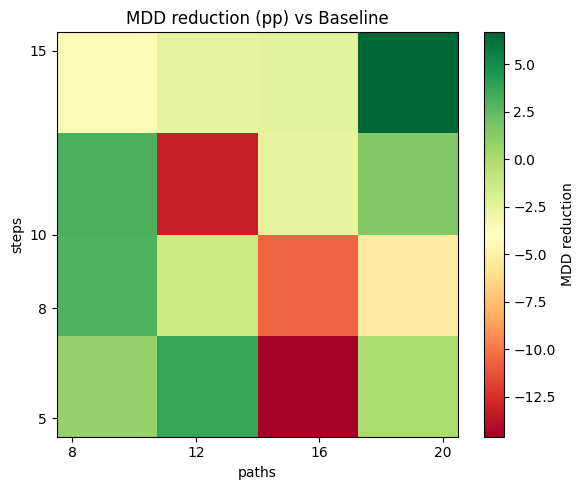

In [70]:
import matplotlib.pyplot as plt
import numpy as np

def plot_param_heatmap(df: pd.DataFrame, value_col="ΔSharpe",
                       agg="max", title=None):
    """
    Heatmap over steps × paths for a metric (e.g., ΔSharpe / MDD reduction).
    """
    pv = df.pivot_table(index="steps", columns="paths", values=value_col, aggfunc=agg)
    steps = pv.index.values; paths = pv.columns.values
    M = pv.values

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(M, origin="lower", aspect="auto",
                   extent=[paths.min()-0.5, paths.max()+0.5, steps.min()-0.5, steps.max()+0.5],
                   cmap="RdYlGn", vmin=np.nanmin(M), vmax=np.nanmax(M))
    ax.set_xlabel("paths"); ax.set_ylabel("steps")
    ax.set_xticks(paths); ax.set_yticks(steps)
    ax.set_title(title or f"Heatmap of {value_col} ({agg})")
    cbar = fig.colorbar(im, ax=ax); cbar.set_label(value_col)
    plt.tight_layout(); plt.show()

# 示例：Sharpe 提升 & 回撤降低的热力图
plot_param_heatmap(cmp_df, value_col="ΔSharpe",      agg="max", title="ΔSharpe vs Baseline")
plot_param_heatmap(cmp_df, value_col="MDD reduction", agg="max", title="MDD reduction (pp) vs Baseline")


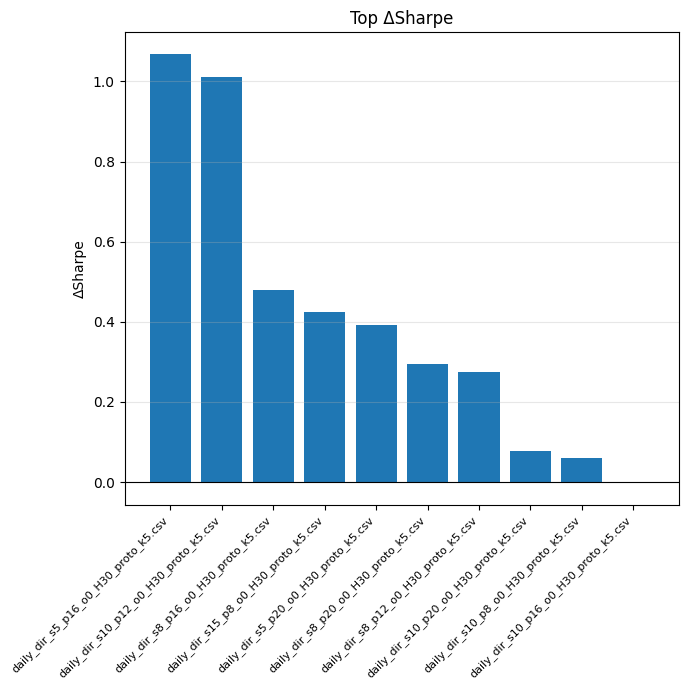

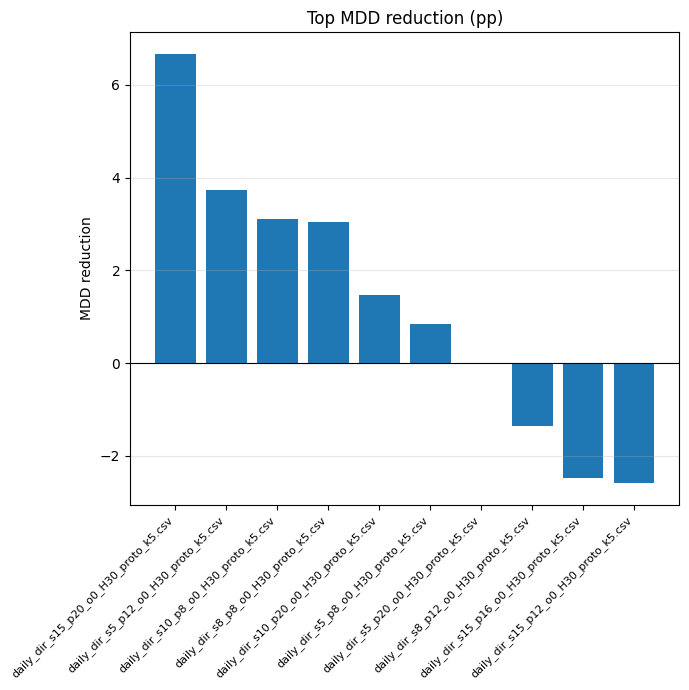

In [78]:
def plot_topk_bars(df: pd.DataFrame, k=10, metric="ΔSharpe", title=None):
    top = df.dropna(subset=[metric]).sort_values(metric, ascending=False).head(k)
    fig, ax = plt.subplots(figsize=(7,7))
    ax.bar(np.arange(len(top)), top[metric])
    ax.set_xticks(np.arange(len(top)))
    ax.set_xticklabels(top["signal_file"], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(metric); ax.set_title(title or f"Top-{k} {metric} vs Baseline")
    ax.axhline(0, color="k", lw=0.8); ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

plot_topk_bars(cmp_df, k=10, metric="ΔSharpe",       title="Top ΔSharpe")
plot_topk_bars(cmp_df, k=10, metric="MDD reduction",  title="Top MDD reduction (pp)")


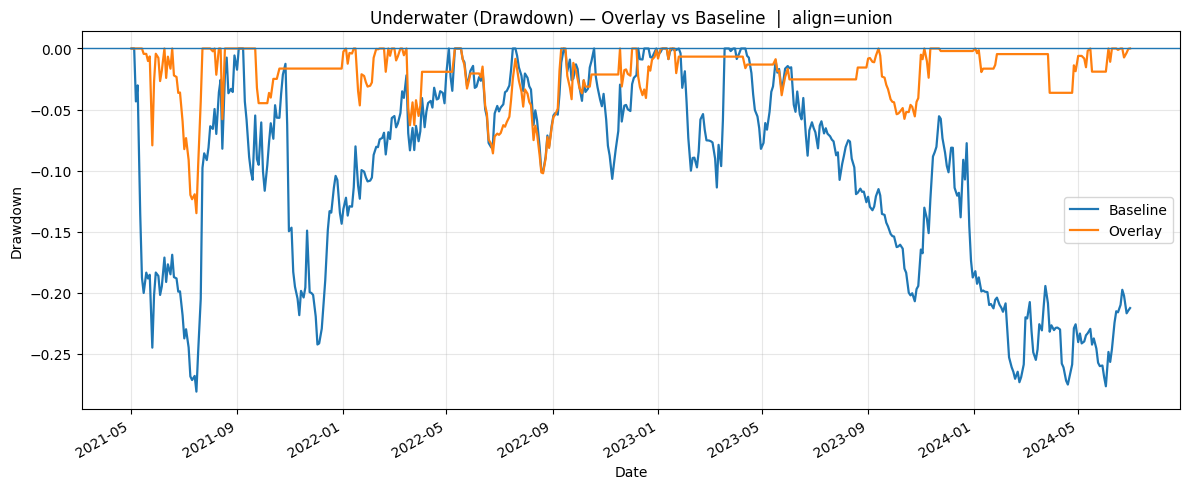

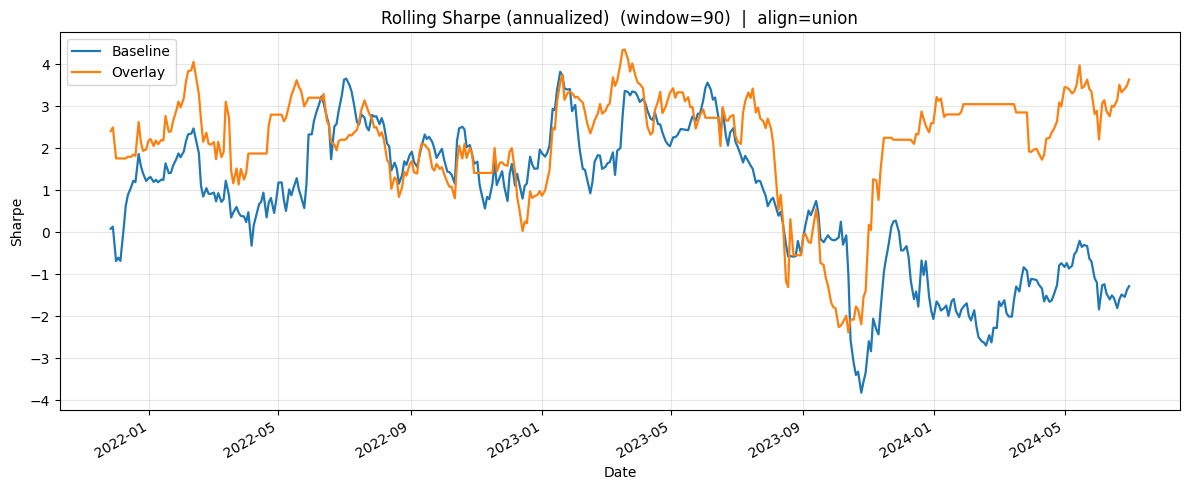

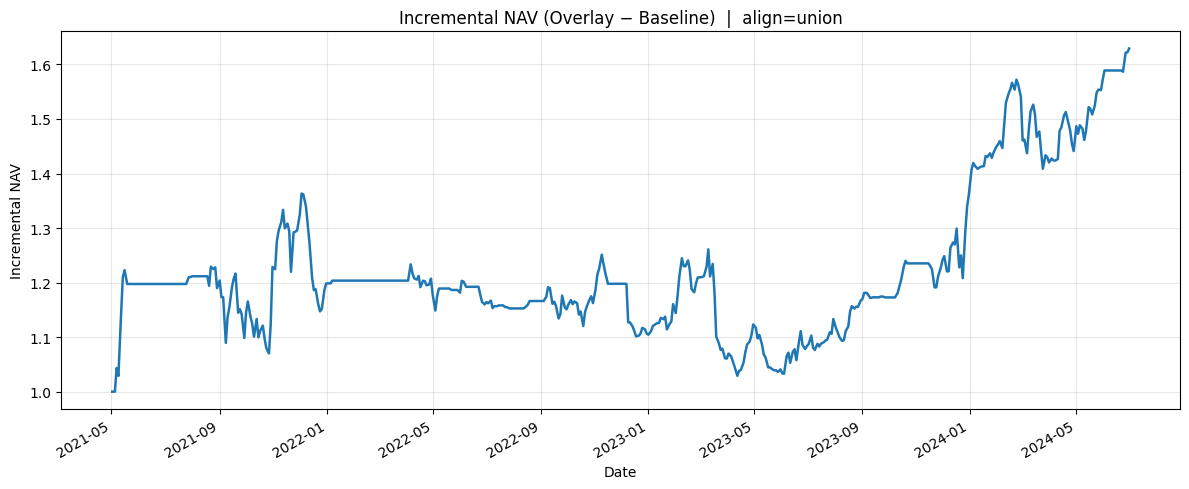

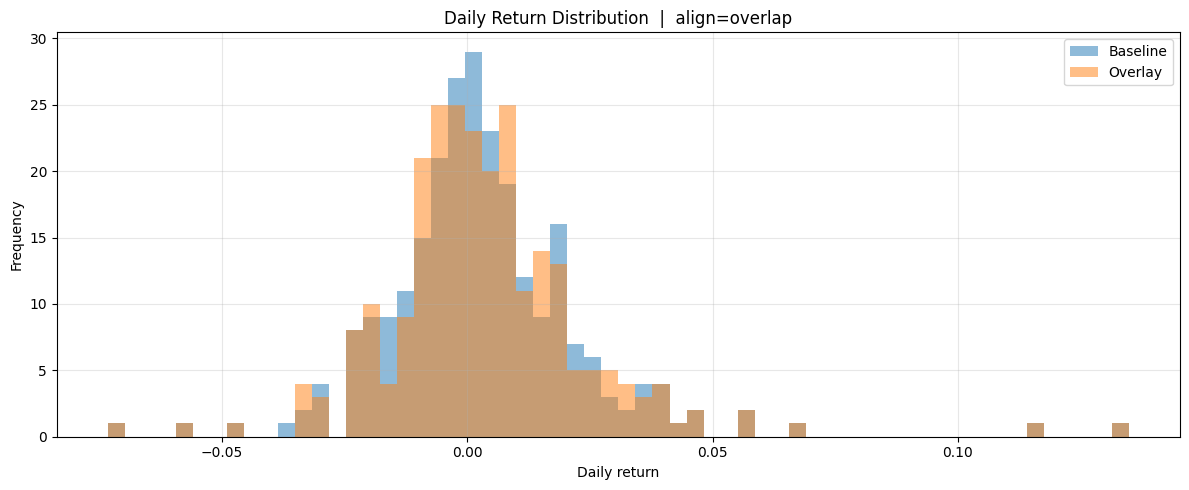

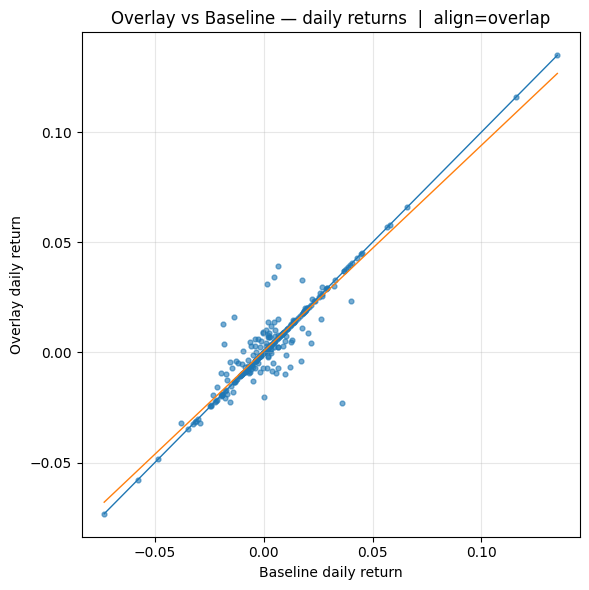

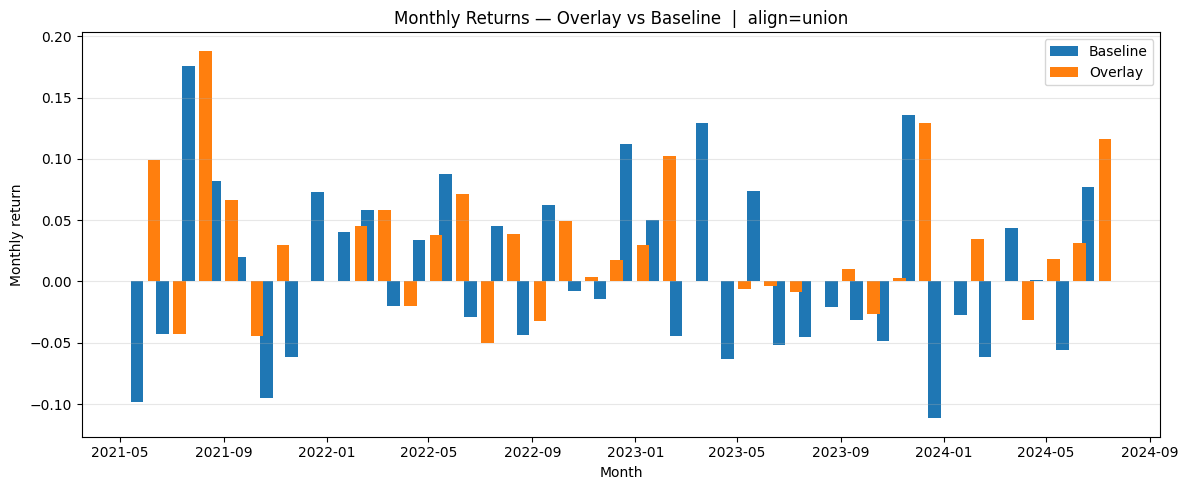

In [81]:
# choose one overlay series from your `rets_map` (e.g., best by Sharpe)
best_name = results.sort_values("Sharpe Ratio", ascending=False).iloc[0]["signal_file"]
ret_overlay = rets_map[best_name]

# (optional) execution-day regime signal for attribution / time-in-market
# sig_exec = your_direction_signal.shift(1).reindex(ret_overlay.index)

plot_underwater_comparison(ret_base, ret_overlay, align="union")
plot_rolling_sharpe(ret_base, ret_overlay, window=90, ann_factor=365, align="union")
plot_incremental_nav(ret_base, ret_overlay, align="union")
plot_return_hist(ret_base, ret_overlay, bins=60, align="overlap")
plot_scatter_overlay_vs_base(ret_base, ret_overlay, align="overlap")
# plot_regime_attribution(ret_base, ret_overlay, sig_exec, align="overlap")
# plot_time_in_market(sig_exec, window=60)
plot_monthly_returns_bars(ret_base, ret_overlay, align="union")
